In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pylab import rcParams
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ziya07/smart-manufacturing-iot-cloud-monitoring-dataset/smart_manufacturing_data.csv


In [10]:
df=pd.read_csv("/kaggle/input/datasets/ziya07/smart-manufacturing-iot-cloud-monitoring-dataset/smart_manufacturing_data.csv")

In [11]:
df.columns #maintenance_required is the target columns for prediction 
#anomaly_flag is the target for anomaly detection

Index(['timestamp', 'machine_id', 'temperature', 'vibration', 'humidity',
       'pressure', 'energy_consumption', 'machine_status', 'anomaly_flag',
       'predicted_remaining_life', 'failure_type', 'downtime_risk',
       'maintenance_required'],
      dtype='object')

In [12]:
df.info() #2 columns with object datatype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   timestamp                 100000 non-null  object 
 1   machine_id                100000 non-null  int64  
 2   temperature               100000 non-null  float64
 3   vibration                 100000 non-null  float64
 4   humidity                  100000 non-null  float64
 5   pressure                  100000 non-null  float64
 6   energy_consumption        100000 non-null  float64
 7   machine_status            100000 non-null  int64  
 8   anomaly_flag              100000 non-null  int64  
 9   predicted_remaining_life  100000 non-null  int64  
 10  failure_type              100000 non-null  object 
 11  downtime_risk             100000 non-null  float64
 12  maintenance_required      100000 non-null  int64  
dtypes: float64(6), int64(5), object(2)
memory usa

In [13]:
#Performing Data Preprocessing
df.isnull().sum()


timestamp                   0
machine_id                  0
temperature                 0
vibration                   0
humidity                    0
pressure                    0
energy_consumption          0
machine_status              0
anomaly_flag                0
predicted_remaining_life    0
failure_type                0
downtime_risk               0
maintenance_required        0
dtype: int64

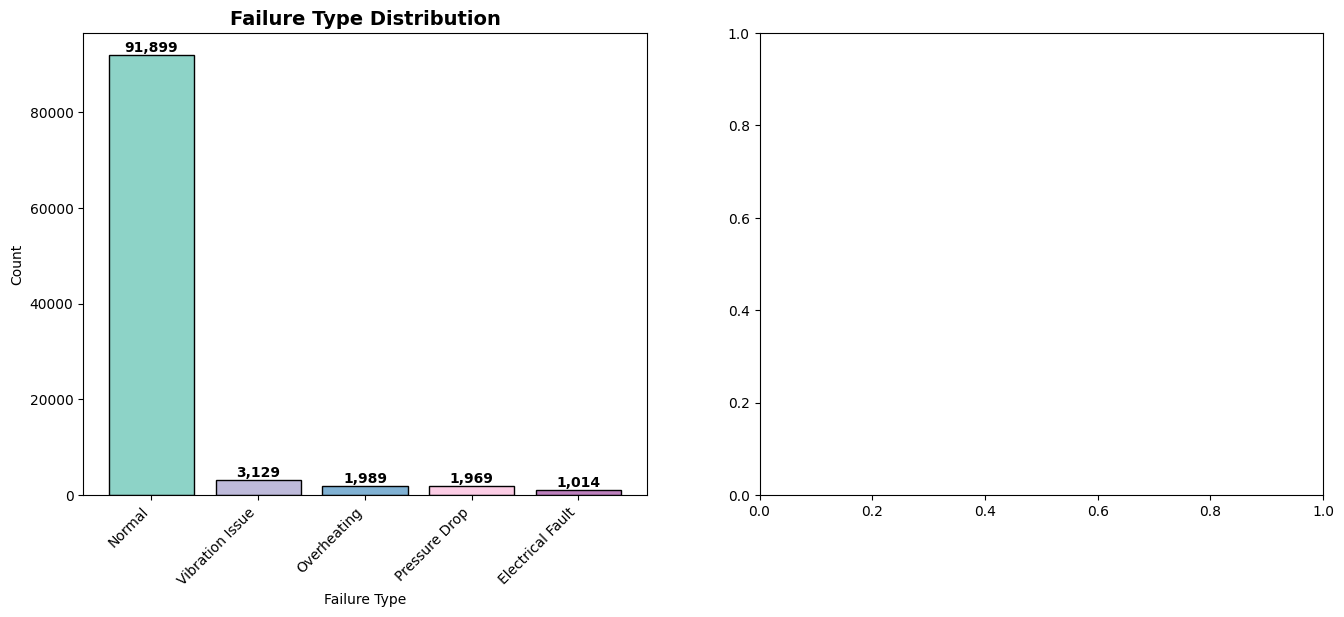

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

failure_counts = df['failure_type'].value_counts()
failure_colors = plt.cm.Set3(np.arange(len(failure_counts))/len(failure_counts))

bars = ax1.bar(range(len(failure_counts)), failure_counts.values, 
               color=failure_colors, edgecolor='black')
ax1.set_title('Failure Type Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Failure Type')
ax1.set_ylabel('Count')
ax1.set_xticks(range(len(failure_counts)))
ax1.set_xticklabels(failure_counts.index, rotation=45, ha='right')

for i, (bar, count) in enumerate(zip(bars, failure_counts.values)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

In [15]:
X=df[[cols for cols in df.columns if cols != "maintenance_required"]]
Y=df["maintenance_required"]
x_train,X_test,y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=42)
x_val,x_test,y_val,y_test=train_test_split(X_test,Y_test,test_size=0.5,random_state=42)

In [16]:
print(x_train.shape,x_val.shape,x_test.shape)

(70000, 12) (15000, 12) (15000, 12)


In [23]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

import numpy as np

# Finding outlier ratio
ratio = len(df[df["maintenance_required"] == 1]) / len(df)

# CUSTOM F1 SCORER
def iso_f1(estimator, X, y):

    preds = estimator.predict(X)

    # Convert IF labels
    # -1 -> anomaly -> 1
    #  1 -> normal  -> 0
    preds = np.where(preds == -1, 1, 0)

    return f1_score(y, preds)

# PIPELINE
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('iso', IsolationForest(
        contamination=ratio,
        random_state=42
    ))
])

# HYPERPARAMETERS
param_dist = {
    'iso__n_estimators': [100, 200, 250],
    'iso__max_samples': [0.5, 0.75, 1.0],
    'iso__max_features': [0.5, 0.75, 1.0]
}

# RANDOMIZED SEARCH
params = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring=iso_f1,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# TRAIN
params.fit(x_train, y_train)

# BEST MODEL
best_model = params.best_estimator_

# PREDICTIONS
predictions = best_model.predict(x_val)

# CONVERT LABELS
predictions = np.where(predictions == -1, 1, 0)

print(predictions[:20])

# ACCURACY
accuracy = accuracy_score(y_val, predictions)

# F1 SCORE
f1 = f1_score(y_val, predictions)

# CONFUSION MATRIX
cm = confusion_matrix(y_val, predictions)

# RESULTS
print("Accuracy:", accuracy)

print("\nF1 Score:", f1)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_val, predictions))

Fitting 3 folds for each of 10 candidates, totalling 30 fits


ValueError: 
All the 30 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 588, in _fit